# Round 5 — Data Exploration

Loads raw `prices_round_5_day_*.csv` and `trades_round_5_day_*.csv` from `backtester/datasets/round5/`.

Round 5 introduces **10 product families × 5 variants each** = 50 instruments, all priced in `XIRECS`. No underlying/option structure — instead, variants within a family likely share a common factor (family mid).

Families:
- **GALAXY_SOUNDS** — BLACK_HOLES, DARK_MATTER, PLANETARY_RINGS, SOLAR_FLAMES, SOLAR_WINDS
- **MICROCHIP** — CIRCLE, OVAL, RECTANGLE, SQUARE, TRIANGLE
- **OXYGEN_SHAKE** — CHOCOLATE, EVENING_BREATH, GARLIC, MINT, MORNING_BREATH
- **PANEL** — 1X2, 1X4, 2X2, 2X4, 4X4
- **PEBBLES** — XS, S, M, L, XL
- **ROBOT** — DISHES, IRONING, LAUNDRY, MOPPING, VACUUMING
- **SLEEP_POD** — COTTON, LAMB_WOOL, NYLON, POLYESTER, SUEDE
- **SNACKPACK** — CHOCOLATE, PISTACHIO, RASPBERRY, STRAWBERRY, VANILLA
- **TRANSLATOR** — ASTRO_BLACK, ECLIPSE_CHARCOAL, GRAPHITE_MIST, SPACE_GRAY, VOID_BLUE
- **UV_VISOR** — AMBER, MAGENTA, ORANGE, RED, YELLOW

In [9]:
# --- Config ---
DATASET_DIR = "../backtester/datasets/round5/"
DAYS = [2, 3, 4]

FAMILIES = {
    "GALAXY_SOUNDS": ["BLACK_HOLES", "DARK_MATTER", "PLANETARY_RINGS", "SOLAR_FLAMES", "SOLAR_WINDS"],
    "MICROCHIP":     ["CIRCLE", "OVAL", "RECTANGLE", "SQUARE", "TRIANGLE"],
    "OXYGEN_SHAKE":  ["CHOCOLATE", "EVENING_BREATH", "GARLIC", "MINT", "MORNING_BREATH"],
    "PANEL":         ["1X2", "1X4", "2X2", "2X4", "4X4"],
    "PEBBLES":       ["XS", "S", "M", "L", "XL"],
    "ROBOT":         ["DISHES", "IRONING", "LAUNDRY", "MOPPING", "VACUUMING"],
    "SLEEP_POD":     ["COTTON", "LAMB_WOOL", "NYLON", "POLYESTER", "SUEDE"],
    "SNACKPACK":     ["CHOCOLATE", "PISTACHIO", "RASPBERRY", "STRAWBERRY", "VANILLA"],
    "TRANSLATOR":    ["ASTRO_BLACK", "ECLIPSE_CHARCOAL", "GRAPHITE_MIST", "SPACE_GRAY", "VOID_BLUE"],
    "UV_VISOR":      ["AMBER", "MAGENTA", "ORANGE", "RED", "YELLOW"],
}
ALL_PRODUCTS = [f"{fam}_{v}" for fam, vs in FAMILIES.items() for v in vs]
print(f"{len(FAMILIES)} families, {len(ALL_PRODUCTS)} products total")

10 families, 50 products total


In [10]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.family": "monospace",
})

print("Ready.")

Ready.


## 1. Load Prices (order book snapshots)

In [11]:
def load_prices(dataset_dir, days):
    frames = []
    for d in days:
        path = Path(dataset_dir) / f"prices_round_5_day_{d}.csv"
        if not path.exists():
            print(f"Missing: {path}")
            continue
        df = pd.read_csv(path, sep=";")
        df["_day"] = d
        df["_global_ts"] = d * 1_000_000 + df["timestamp"].astype(np.int64)
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

prices = load_prices(DATASET_DIR, DAYS)
print(f"Loaded {len(prices):,} price rows")
if len(prices):
    products = sorted(prices["product"].unique())
    print(f"Products ({len(products)}):")
    for p in products:
        print(f"  {p}")

# Pivot to ts × product → mid_price (used by every downstream cell, O(1) lookups)
mid_wide = (
    prices.pivot_table(index="_global_ts", columns="product", values="mid_price", aggfunc="first")
    if len(prices) else pd.DataFrame()
)
print(f"mid_wide shape: {mid_wide.shape}")

Loaded 1,500,000 price rows
Products (50):
  GALAXY_SOUNDS_BLACK_HOLES
  GALAXY_SOUNDS_DARK_MATTER
  GALAXY_SOUNDS_PLANETARY_RINGS
  GALAXY_SOUNDS_SOLAR_FLAMES
  GALAXY_SOUNDS_SOLAR_WINDS
  MICROCHIP_CIRCLE
  MICROCHIP_OVAL
  MICROCHIP_RECTANGLE
  MICROCHIP_SQUARE
  MICROCHIP_TRIANGLE
  OXYGEN_SHAKE_CHOCOLATE
  OXYGEN_SHAKE_EVENING_BREATH
  OXYGEN_SHAKE_GARLIC
  OXYGEN_SHAKE_MINT
  OXYGEN_SHAKE_MORNING_BREATH
  PANEL_1X2
  PANEL_1X4
  PANEL_2X2
  PANEL_2X4
  PANEL_4X4
  PEBBLES_L
  PEBBLES_M
  PEBBLES_S
  PEBBLES_XL
  PEBBLES_XS
  ROBOT_DISHES
  ROBOT_IRONING
  ROBOT_LAUNDRY
  ROBOT_MOPPING
  ROBOT_VACUUMING
  SLEEP_POD_COTTON
  SLEEP_POD_LAMB_WOOL
  SLEEP_POD_NYLON
  SLEEP_POD_POLYESTER
  SLEEP_POD_SUEDE
  SNACKPACK_CHOCOLATE
  SNACKPACK_PISTACHIO
  SNACKPACK_RASPBERRY
  SNACKPACK_STRAWBERRY
  SNACKPACK_VANILLA
  TRANSLATOR_ASTRO_BLACK
  TRANSLATOR_ECLIPSE_CHARCOAL
  TRANSLATOR_GRAPHITE_MIST
  TRANSLATOR_SPACE_GRAY
  TRANSLATOR_VOID_BLUE
  UV_VISOR_AMBER
  UV_VISOR_MAGENTA
  UV_VISOR_

## 2. Per-product price summary

In [12]:
if len(mid_wide):
    summary = mid_wide.agg(["count", "mean", "min", "max", "std"]).T
    summary = summary.rename(columns={"count": "n", "std": "stdev"})
    summary["n"] = summary["n"].astype(int)
    for fam, variants in FAMILIES.items():
        cols = [f"{fam}_{v}" for v in variants if f"{fam}_{v}" in summary.index]
        print(f"\n--- {fam} ---")
        print(summary.loc[cols].round(2).to_string())


--- GALAXY_SOUNDS ---
                                   n      mean     min      max   stdev
product                                                                
GALAXY_SOUNDS_BLACK_HOLES      30000  11466.87  9608.5  14137.0  958.44
GALAXY_SOUNDS_DARK_MATTER      30000  10226.66  9541.0  11186.0  330.70
GALAXY_SOUNDS_PLANETARY_RINGS  30000  10766.67  9253.0  12182.0  765.84
GALAXY_SOUNDS_SOLAR_FLAMES     30000  11092.57  9837.5  12210.0  450.15
GALAXY_SOUNDS_SOLAR_WINDS      30000  10437.54  9320.0  11613.5  541.11

--- MICROCHIP ---
                         n      mean     min      max    stdev
product                                                       
MICROCHIP_CIRCLE     30000   9214.89  8303.5  10731.5   532.51
MICROCHIP_OVAL       30000   8179.60  5375.0  10433.0  1551.91
MICROCHIP_RECTANGLE  30000   8732.44  7327.5  10442.5   752.02
MICROCHIP_SQUARE     30000  13594.75  9756.0  16498.0  1830.25
MICROCHIP_TRIANGLE   30000   9686.39  7749.0  10872.0   833.37

--- OXYGEN_S

## 3. Mid price per family — variants overlaid

One subplot per family, all 5 variants on the same axis. Tight co-movement → suggests a shared factor / family mid that variants oscillate around.

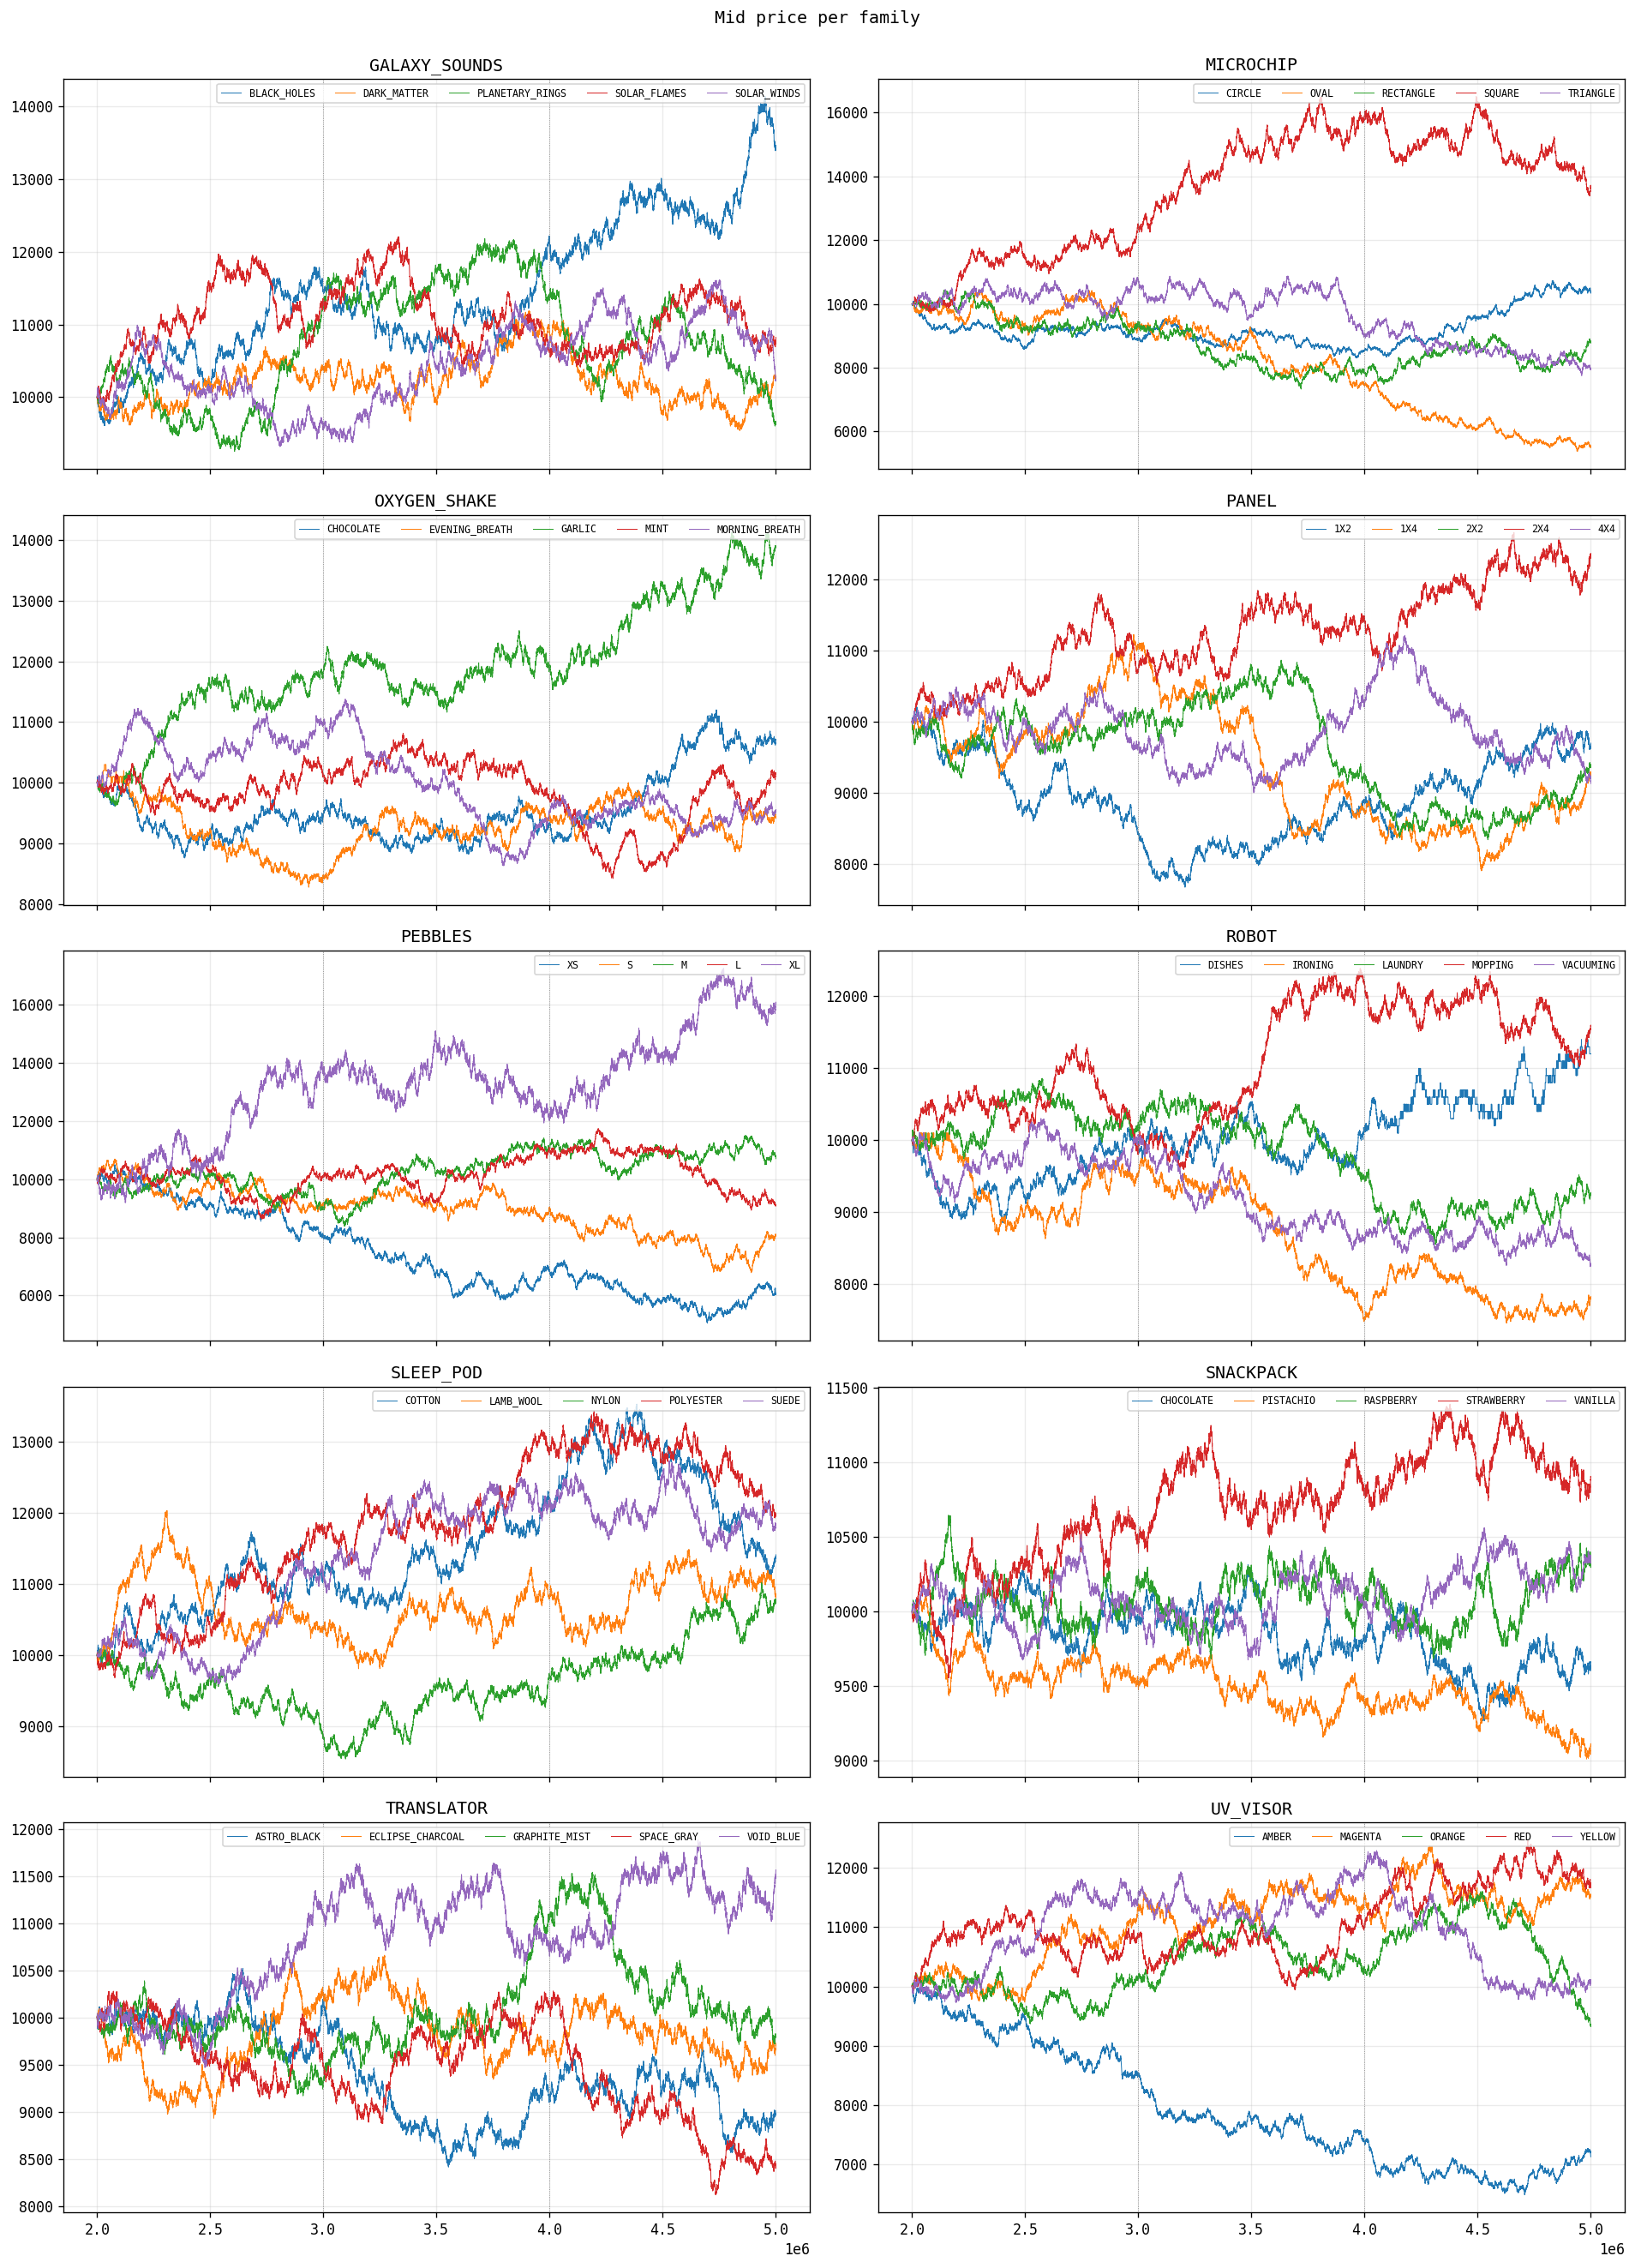

In [13]:
if len(mid_wide):
    fig, axes = plt.subplots(5, 2, figsize=(16, 22), sharex=True)
    cmap = plt.get_cmap("tab10")
    ts = mid_wide.index.to_numpy()
    for ax, (fam, variants) in zip(axes.flat, FAMILIES.items()):
        for i, v in enumerate(variants):
            col = f"{fam}_{v}"
            if col not in mid_wide.columns:
                continue
            ax.plot(ts, mid_wide[col].to_numpy(), linewidth=0.6, color=cmap(i), label=v)
        for d in DAYS[1:]:
            ax.axvline(d * 1_000_000, color="gray", linestyle=":", linewidth=0.5)
        ax.set_title(fam)
        ax.legend(fontsize=7, ncol=5, loc="upper right")
        ax.grid(True, alpha=0.25)
    fig.suptitle("Mid price per family", y=1.00)
    plt.tight_layout()
    plt.show()

## 4. Within-family spread (variant − family mean)

If variants share a common factor, the deviation (variant_mid − mean of family at that ts) is the **idiosyncratic component**. Persistent deviations suggest mean-reverting pair/basket trades within the family.

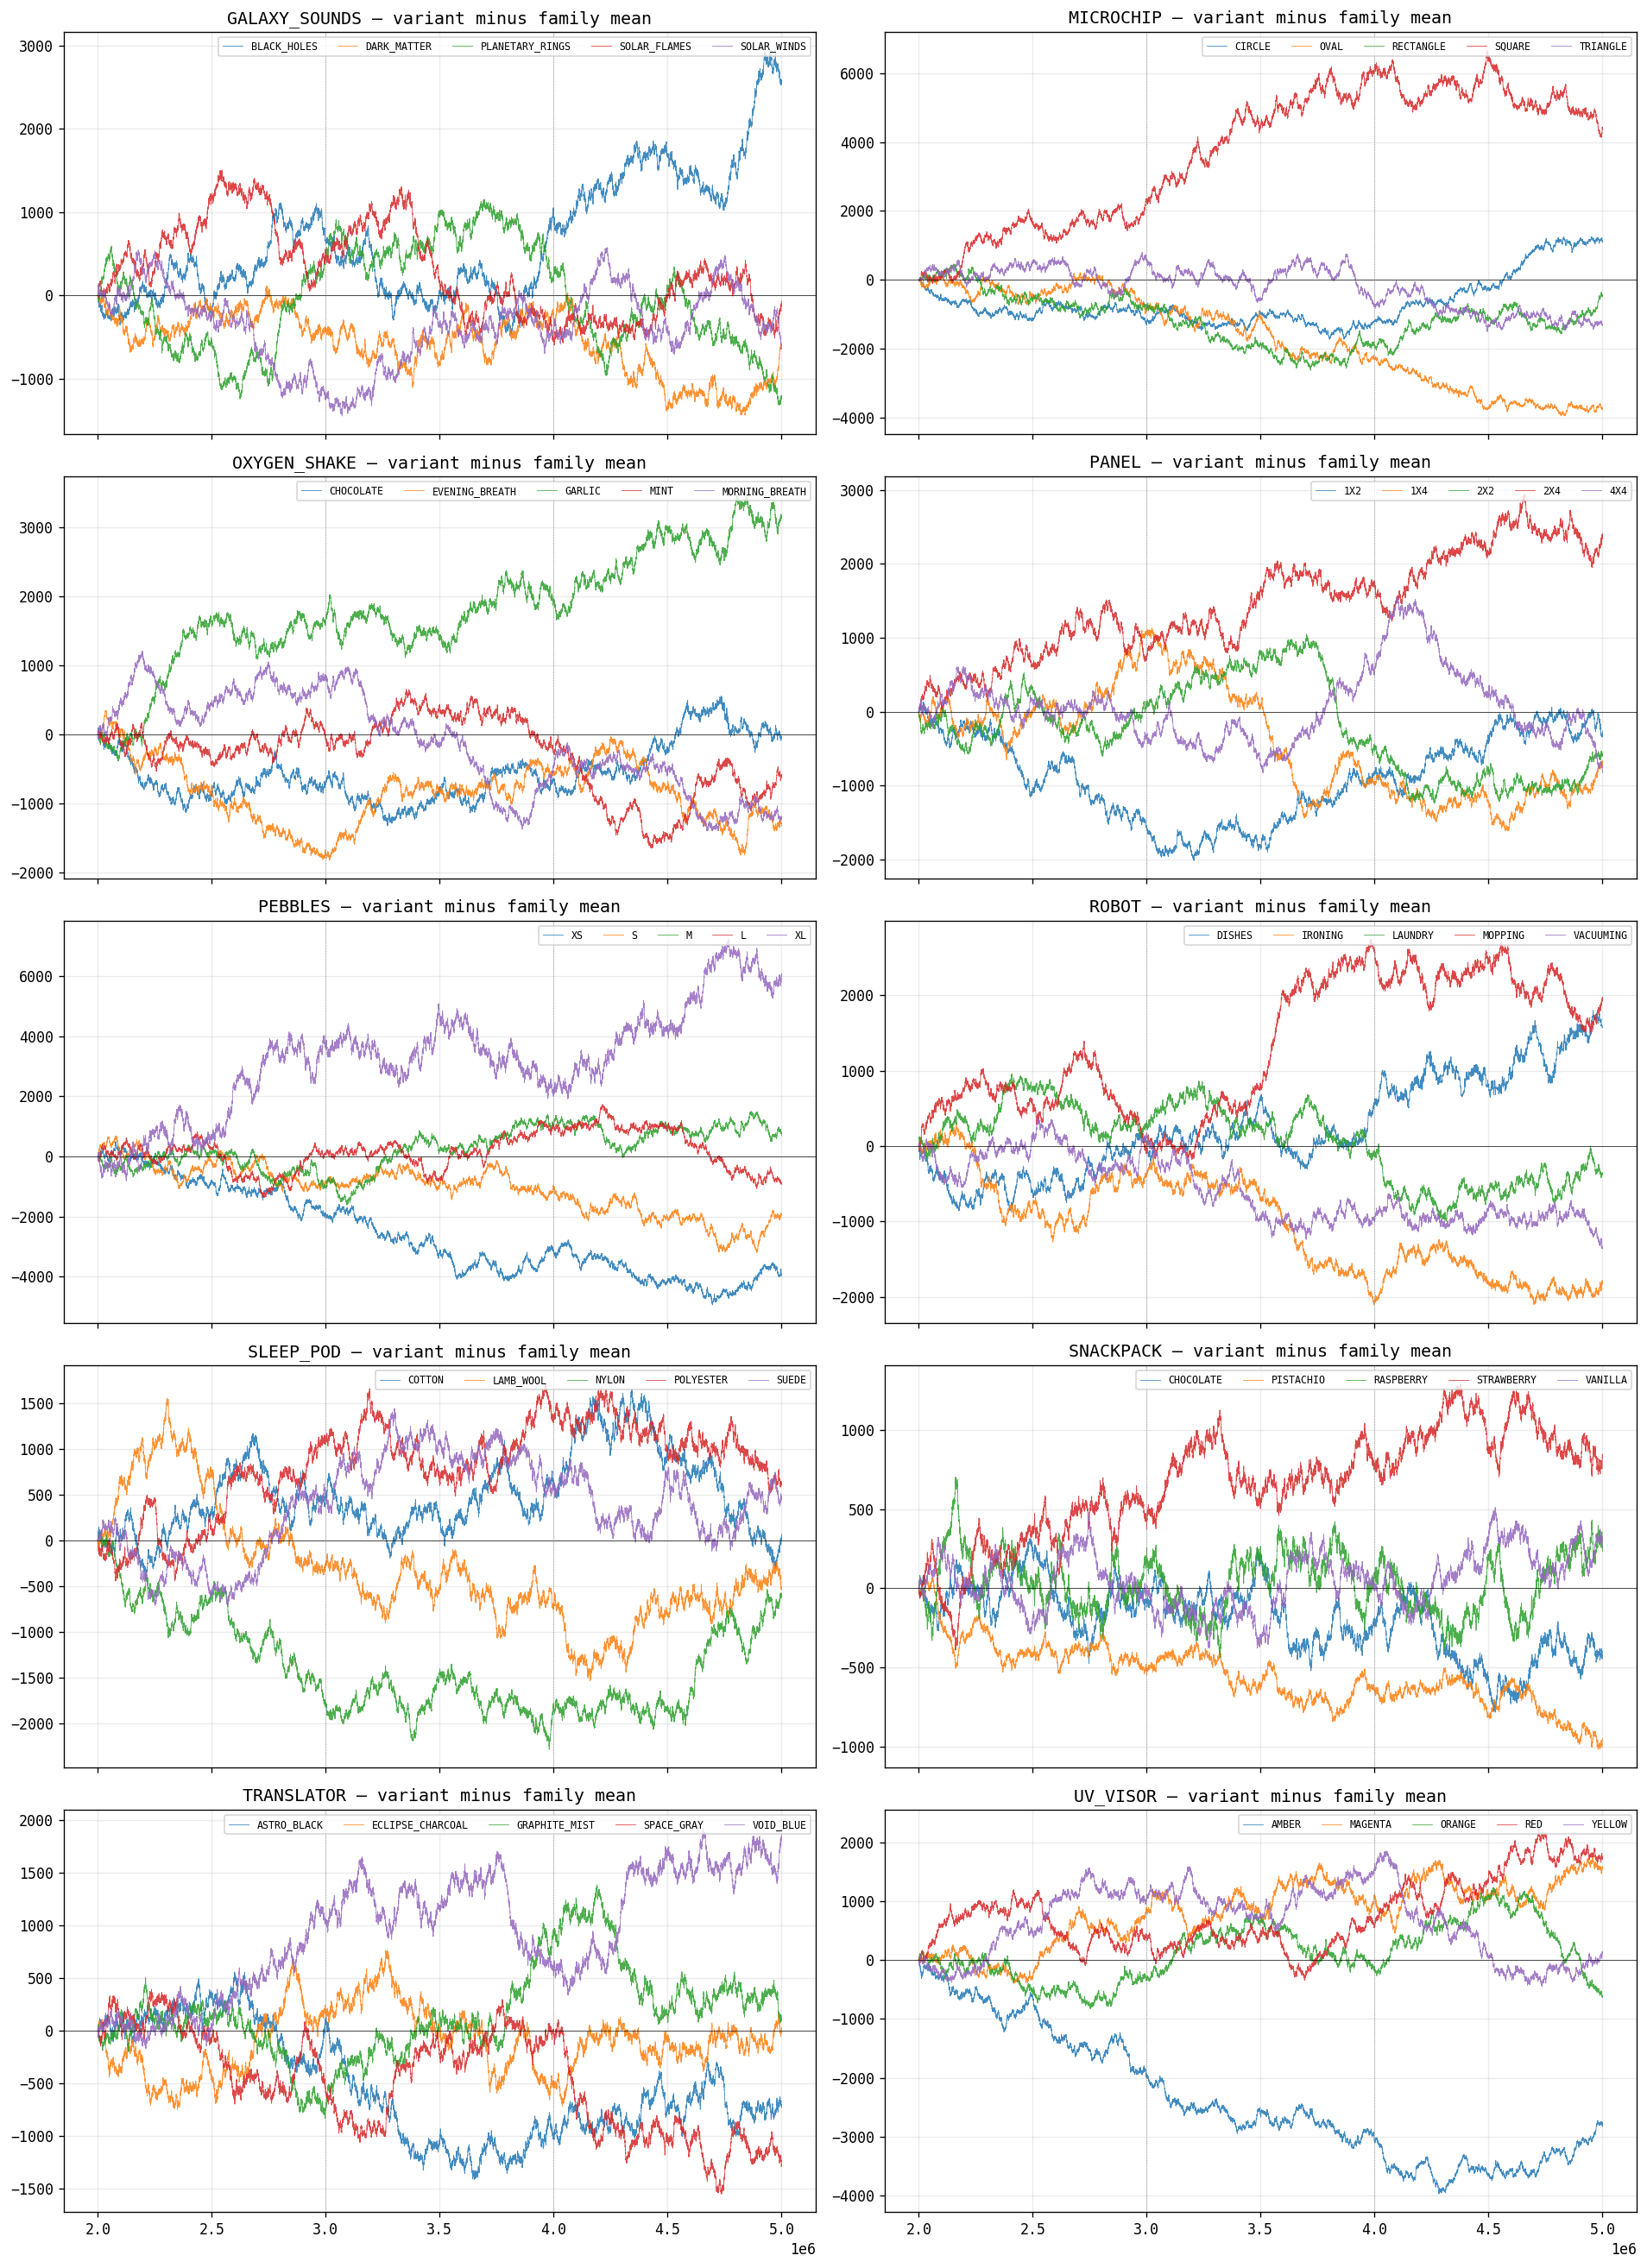

In [14]:
if len(mid_wide):
    fig, axes = plt.subplots(5, 2, figsize=(16, 22), sharex=True)
    cmap = plt.get_cmap("tab10")
    ts = mid_wide.index.to_numpy()
    for ax, (fam, variants) in zip(axes.flat, FAMILIES.items()):
        cols = [f"{fam}_{v}" for v in variants if f"{fam}_{v}" in mid_wide.columns]
        if not cols:
            continue
        sub = mid_wide[cols]
        fam_mean = sub.mean(axis=1)
        for i, v in enumerate(variants):
            col = f"{fam}_{v}"
            if col not in sub.columns:
                continue
            ax.plot(ts, (sub[col] - fam_mean).to_numpy(),
                    linewidth=0.5, color=cmap(i), label=v, alpha=0.85)
        ax.axhline(0, color="black", linewidth=0.4)
        for d in DAYS[1:]:
            ax.axvline(d * 1_000_000, color="gray", linestyle=":", linewidth=0.5)
        ax.set_title(f"{fam} — variant minus family mean")
        ax.legend(fontsize=7, ncol=5, loc="upper right")
        ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

## 5. Within-family correlation matrix

Pearson correlation of 1-tick mid-price changes across the 5 variants. High positive corr → shared factor. Negative or near-zero corr → independent products that happen to share a name.

In [15]:
if len(mid_wide):
    diffs_wide = mid_wide.diff()
    for fam, variants in FAMILIES.items():
        cols = [f"{fam}_{v}" for v in variants if f"{fam}_{v}" in diffs_wide.columns]
        if len(cols) < 2:
            continue
        cm = diffs_wide[cols].corr()
        print(f"\n{fam}")
        print(cm.round(3).to_string())


GALAXY_SOUNDS
product                        GALAXY_SOUNDS_BLACK_HOLES  GALAXY_SOUNDS_DARK_MATTER  GALAXY_SOUNDS_PLANETARY_RINGS  GALAXY_SOUNDS_SOLAR_FLAMES  GALAXY_SOUNDS_SOLAR_WINDS
product                                                                                                                                                                  
GALAXY_SOUNDS_BLACK_HOLES                          1.000                      0.000                          0.002                       0.002                      0.010
GALAXY_SOUNDS_DARK_MATTER                          0.000                      1.000                          0.006                       0.004                     -0.001
GALAXY_SOUNDS_PLANETARY_RINGS                      0.002                      0.006                          1.000                       0.014                     -0.000
GALAXY_SOUNDS_SOLAR_FLAMES                         0.002                      0.004                          0.014                     

## 6. Bid/Ask spread per product

In [16]:
if len(prices):
    sp = prices.dropna(subset=["bid_price_1", "ask_price_1"]).copy()
    sp["spread"] = sp["ask_price_1"] - sp["bid_price_1"]
    out = sp.groupby("product")["spread"].agg(["count", "mean", "min", "max"]).sort_values("mean", ascending=False)
    out["count"] = out["count"].astype(int)
    print(out.round(2).to_string())

                               count   mean  min  max
product                                              
SNACKPACK_STRAWBERRY           30000  17.83    7   20
SNACKPACK_VANILLA              30000  16.87    7   18
SNACKPACK_RASPBERRY            30000  16.84    7   18
PEBBLES_XL                     30000  16.63    5   22
SNACKPACK_CHOCOLATE            30000  16.47    7   18
SNACKPACK_PISTACHIO            30000  15.93    7   18
OXYGEN_SHAKE_GARLIC            30000  15.05    5   18
GALAXY_SOUNDS_BLACK_HOLES      30000  14.51    5   18
UV_VISOR_MAGENTA               30000  14.09    5   16
GALAXY_SOUNDS_SOLAR_FLAMES     30000  14.07    6   16
UV_VISOR_RED                   30000  14.04    6   16
UV_VISOR_YELLOW                30000  13.91    5   16
GALAXY_SOUNDS_PLANETARY_RINGS  30000  13.69    5   16
GALAXY_SOUNDS_SOLAR_WINDS      30000  13.30    5   15
UV_VISOR_ORANGE                30000  13.28    5   15
PEBBLES_M                      30000  13.12    5   15
GALAXY_SOUNDS_DARK_MATTER   

## 7. Load Trades

In [17]:
def load_trades(dataset_dir, days):
    frames = []
    for d in days:
        path = Path(dataset_dir) / f"trades_round_5_day_{d}.csv"
        if not path.exists():
            print(f"Missing: {path}")
            continue
        # auto-detect delimiter
        sample = path.read_text()[:2048]
        delim = ";" if sample.count(";") > sample.count(",") else ","
        df = pd.read_csv(path, sep=delim)
        df["_day"] = d
        df["_global_ts"] = d * 1_000_000 + df["timestamp"].astype(np.int64)
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

trades = load_trades(DATASET_DIR, DAYS)
print(f"Loaded {len(trades):,} trades")
if len(trades):
    print(f"Columns: {list(trades.columns)}")

Loaded 35,385 trades
Columns: ['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price', 'quantity', '_day', '_global_ts']


## 8. Trade volume & notional per product

In [18]:
if len(trades):
    sym_key = "symbol" if "symbol" in trades.columns else "product"
    t = trades.copy()
    t["quantity"] = pd.to_numeric(t["quantity"], errors="coerce").abs()
    t["price"] = pd.to_numeric(t["price"], errors="coerce")
    t = t.dropna(subset=["quantity", "price"])
    t["notional"] = t["quantity"] * t["price"]
    out = t.groupby(sym_key).agg(volume=("quantity", "sum"), notional=("notional", "sum")).sort_values("volume", ascending=False)
    out["volume"] = out["volume"].astype(int)
    print(out.round(0).to_string())

                               volume    notional
symbol                                           
PEBBLES_XS                       2283  16966956.0
PEBBLES_XL                       2283  30098849.0
PEBBLES_S                        2283  20465803.0
PEBBLES_M                        2283  23349411.0
PEBBLES_L                        2283  23268563.0
GALAXY_SOUNDS_BLACK_HOLES        1805  20710823.0
SNACKPACK_PISTACHIO              1805  17119880.0
SLEEP_POD_COTTON                 1805  20797483.0
SLEEP_POD_LAMB_WOOL              1805  19323947.0
SLEEP_POD_NYLON                  1805  17374803.0
SLEEP_POD_POLYESTER              1805  21410073.0
SLEEP_POD_SUEDE                  1805  20672132.0
SNACKPACK_CHOCOLATE              1805  17776113.0
SNACKPACK_RASPBERRY              1805  18208675.0
ROBOT_MOPPING                    1805  20063291.0
SNACKPACK_STRAWBERRY             1805  19321708.0
SNACKPACK_VANILLA                1805  18212060.0
TRANSLATOR_ASTRO_BLACK           1805  16890327.0


## 9. Per-family realized vol

1-tick log-return stdev for each variant, scaled to a 10,000-tick day. Helps sort variants by trade-ability vs noise.

In [19]:
if len(mid_wide):
    log_ret = np.log(mid_wide).diff()
    sd = log_ret.std()
    n = log_ret.count().astype(int)
    per_day = sd * math.sqrt(10_000)
    rep = pd.DataFrame({"n": n, "tick_sd": sd, "per_day_pct": per_day * 100})
    for fam, variants in FAMILIES.items():
        cols = [f"{fam}_{v}" for v in variants if f"{fam}_{v}" in rep.index]
        print(f"\n--- {fam} ---")
        print(rep.loc[cols].round({"tick_sd": 6, "per_day_pct": 2}).to_string())


--- GALAXY_SOUNDS ---
                                   n   tick_sd  per_day_pct
product                                                    
GALAXY_SOUNDS_BLACK_HOLES      29999  0.000997         9.97
GALAXY_SOUNDS_DARK_MATTER      29999  0.001002        10.02
GALAXY_SOUNDS_PLANETARY_RINGS  29999  0.001009        10.09
GALAXY_SOUNDS_SOLAR_FLAMES     29999  0.001000        10.00
GALAXY_SOUNDS_SOLAR_WINDS      29999  0.001009        10.09

--- MICROCHIP ---
                         n   tick_sd  per_day_pct
product                                          
MICROCHIP_CIRCLE     29999  0.000999         9.99
MICROCHIP_OVAL       29999  0.001499        14.99
MICROCHIP_RECTANGLE  29999  0.001499        14.99
MICROCHIP_SQUARE     29999  0.001508        15.08
MICROCHIP_TRIANGLE   29999  0.001491        14.91

--- OXYGEN_SHAKE ---
                                 n   tick_sd  per_day_pct
product                                                  
OXYGEN_SHAKE_CHOCOLATE       29999  0.001117      